# Stock Breakout Detection Pipeline (Champion Model)
### Quantitative Machine Learning Architecture Across 50 US Equities

This notebook provides the streamlined, production-grade implementation of the breakout detection model.
It focuses directly on the **inherently tuned base model** (`model.predict()` without manual threshold filtering) designed to solve the asymmetric risk problem in quantitative trading:
- **Core Priority**: Minimizing **False Positives (Deadly Bull Traps)** while maximizing **Breakout Precision (Win Rate)**.
- **Acceptable Trade-off**: Allowing higher **False Negatives (Missed Breakouts)** since missed trades preserve capital in cash without monetary loss.
- **Dataset**: 3,474 validated breakout events across 50 liquid US large-cap equities (2000–2026).
- **Features**: 17 Day-0 technical indicators strictly calculated at or before the breakout close (Zero Lookahead Bias).
- **Split**: 80/20 Chronological Time-Series Partition (Train: 2000–2021, Out-of-Sample Test: 2021–2026).


## 1. Environment Setup & Dependencies
Import core analytical, modeling, and visualization libraries.


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import xgboost as xgb

# Visual aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5.5)
plt.rcParams["font.size"] = 11

print(f"XGBoost version: {xgb.__version__}")


XGBoost version: 3.4.1


## 2. Dataset Ingestion & Target Definition
Load the unified breakout dataset and encode the binary target:
- **`Breakout` (Class 1)**: Price maintained clearance above resistance for $\ge 4$ of 5 confirmation sessions.
- **`Fakeout` (Class 0)**: Price failed and reversed below resistance for $\ge 3$ of 5 confirmation sessions.


In [2]:
df = pd.read_csv("data/unified_breakout_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df["Target"] = (df["Label"] == "breakout").astype(int)

print("=" * 60)
print("DATASET INTEGRITY SUMMARY")
print("=" * 60)
print(f"Total Breakout Events:      {len(df):,} setups")
print(f"Equities Represented:       {df['Ticker'].nunique()} large-cap stocks")
print(f"Historical Coverage:        {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Missing Values:             {df.isna().sum().sum()} nulls")
print("-" * 60)
print(f"Breakouts (Class 1):        {(df['Target'] == 1).sum():,} ({(df['Target'] == 1).mean()*100:.1f}%)")
print(f"Fakeouts  (Class 0):        {(df['Target'] == 0).sum():,} ({(df['Target'] == 0).mean()*100:.1f}%)")
print("=" * 60)


DATASET INTEGRITY SUMMARY
Total Breakout Events:      3,474 setups
Equities Represented:       50 large-cap stocks
Historical Coverage:        2000-02-18 to 2026-07-16
Missing Values:             0 nulls
------------------------------------------------------------
Breakouts (Class 1):        2,861 (82.4%)
Fakeouts  (Class 0):        613 (17.6%)


## 3. Feature Matrix & Chronological Train/Test Split
Select the 17 predictive Day-0 technical features and split chronologically (80% Train, 20% Out-of-Sample Test).


In [3]:
feature_cols = [
    "Resistance_Distance_%",
    "Close_Position",
    "Volume_Ratio",
    "Volume_Surge_10",
    "Distance_MA10_%",
    "Distance_MA30_%",
    "MA_Ratio",
    "Momentum_5d_%",
    "Momentum_10d_%",
    "Momentum_20d_%",
    "ATR_Pct",
    "Daily_Range_%",
    "Range_Ratio",
    "Volatility_10d",
    "Price_Range_10d_%",
    "RSI_14",
    "Breakout_Pct"
]

split_idx = int(len(df) * 0.80)
split_date = df.loc[split_idx, "Date"]

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train, y_train = train_df[feature_cols], train_df["Target"]
X_test, y_test = test_df[feature_cols], test_df["Target"]

print(f"Chronological Cutoff Date: {split_date.strftime('%Y-%m-%d')}")
print(f"  Training Period (2000–2021):  {len(train_df):,} samples ({sum(y_train==1)} Breakouts, {sum(y_train==0)} Fakeouts)")
print(f"  Testing Period  (2021–2026):  {len(test_df):,} samples ({sum(y_test==1)} Breakouts, {sum(y_test==0)} Fakeouts)")


Chronological Cutoff Date: 2021-03-22
  Training Period (2000–2021):  2,779 samples (2284 Breakouts, 495 Fakeouts)
  Testing Period  (2021–2026):  695 samples (577 Breakouts, 118 Fakeouts)


## 4. Train Asymmetric Cost-Sensitive XGBoost Model
To train the base model to prioritize capital preservation:
- We penalize missing a `fakeout` trap with an asymmetric loss weight of **$w_{\text{fakeout}} = 5.0$**.
- Tree regularization (`min_child_weight = 3`, `reg_lambda = 2.0`, `subsample = 0.8`) prevents overfitting on the majority class.


In [4]:
# 5.0x penalty weight on minority fakeout class
sample_weights = np.where(y_train == 0, 5.0, 1.0)

model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.02,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)
print("Cost-Sensitive XGBoost model trained successfully.")


Cost-Sensitive XGBoost model trained successfully.


## 5. Full Performance & Financial Risk Evaluation Matrix
This section presents the **raw base model predictions** (`model.predict()` at the default 0.50 probability threshold) with zero post-processing tricks.

### 5.1 Financial Outcome Classification:
- **True Positives (TP)**: Actual Breakouts predicted as Breakouts $\rightarrow$ **Profitable Long Trades Executed 🟢**.
- **True Negatives (TN)**: Actual Fakeouts predicted as Fakeouts $\rightarrow$ **Bull Traps Successfully Avoided 🛡️**.
- **False Positives (FP) [DEADLY ERROR]**: Actual Fakeouts predicted as Breakouts $\rightarrow$ **Bull Traps Mistakenly Entered 🔴**.
- **False Negatives (FN) [ACCEPTABLE ERROR]**: Actual Breakouts predicted as Fakeouts $\rightarrow$ **Missed Opportunities (Capital Safely in Cash ⚪)**.


In [5]:
# Pure base predictions (Default cutoff = 0.50)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Extract Confusion Matrix components
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

total_events = len(y_test)
total_fakeouts = tn + fp
total_breakouts = fn + tp

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
bo_prec = precision_score(y_test, y_pred, pos_label=1)
bo_rec = recall_score(y_test, y_pred, pos_label=1)
fo_rec = recall_score(y_test, y_pred, pos_label=0)
fo_prec = precision_score(y_test, y_pred, pos_label=0)

# Build Comprehensive Audit DataFrame
audit_table = pd.DataFrame([
    {
        "Category": "True Positives (TP)",
        "Count": tp,
        "Percentage of Class": f"{tp / total_breakouts * 100:.1f}% of Breakouts",
        "Financial Impact": "Profitable Long Trades Taken (+Return)",
        "Risk Level": "Profitable 🟢"
    },
    {
        "Category": "True Negatives (TN)",
        "Count": tn,
        "Percentage of Class": f"{tn / total_fakeouts * 100:.1f}% of Fakeouts",
        "Financial Impact": "Bull Traps Avoided (Capital Protected)",
        "Risk Level": "Protected 🛡️"
    },
    {
        "Category": "False Positives (FP)",
        "Count": fp,
        "Percentage of Class": f"{fp / total_fakeouts * 100:.1f}% of Fakeouts",
        "Financial Impact": "Bull Traps Mistakenly Entered (Monetary Loss)",
        "Risk Level": "Deadly Error 🔴"
    },
    {
        "Category": "False Negatives (FN)",
        "Count": fn,
        "Percentage of Class": f"{fn / total_breakouts * 100:.1f}% of Breakouts",
        "Financial Impact": "Missed Breakouts (Zero Capital Loss, Cash Safe)",
        "Risk Level": "Acceptable ⚪"
    }
])

print("=" * 80)
print("FINANCIAL RISK & MATRIX AUDIT REPORT (BASE MODEL)")
print("=" * 80)
display(audit_table)

print("\n" + "=" * 80)
print("CORE QUANTITATIVE METRICS SUMMARY")
print("=" * 80)
print(f"Overall Accuracy:                  {acc * 100:.2f}%")
print(f"ROC-AUC Discrimination Score:      {auc:.4f}")
print(f"Breakout Precision (Win Rate):     {bo_prec * 100:.2f}%  <-- [TP / (TP + FP)]")
print(f"Breakout Recall (Market Capture):  {bo_rec * 100:.2f}%  <-- [TP / (TP + FN)]")
print(f"Fakeout Recall (Traps Avoided):    {fo_rec * 100:.2f}%  <-- [TN / (TN + FP)]")
print(f"Fakeout Precision (Trap Conviction):{fo_prec * 100:.2f}%  <-- [TN / (TN + FN)]")
print("=" * 80)


FINANCIAL RISK & MATRIX AUDIT REPORT (BASE MODEL)


,Category,Count,Percentage of Class,Financial Impact,Risk Level
0,True Positives (TP),346,60.0% of Breakouts,Profitable Long Trades Taken (+Return),Profitable 🟢
1,True Negatives (TN),80,67.8% of Fakeouts,Bull Traps Avoided (Capital Protected),Protected 🛡️
2,False Positives (FP),38,32.2% of Fakeouts,Bull Traps Mistakenly Entered (Monetary Loss),Deadly Error 🔴
3,False Negatives (FN),231,40.0% of Breakouts,"Missed Breakouts (Zero Capital Loss, Cash Safe)",Acceptable ⚪



CORE QUANTITATIVE METRICS SUMMARY
Overall Accuracy:                  61.29%
ROC-AUC Discrimination Score:      0.6708
Breakout Precision (Win Rate):     90.10%  <-- [TP / (TP + FP)]
Breakout Recall (Market Capture):  59.97%  <-- [TP / (TP + FN)]
Fakeout Recall (Traps Avoided):    67.80%  <-- [TN / (TN + FP)]
Fakeout Precision (Trap Conviction):25.72%  <-- [TN / (TN + FN)]


### 5.2 Visual Confusion Matrix & ROC Curve
Annotated Confusion Matrix showing exact event counts and labels alongside the ROC curve.


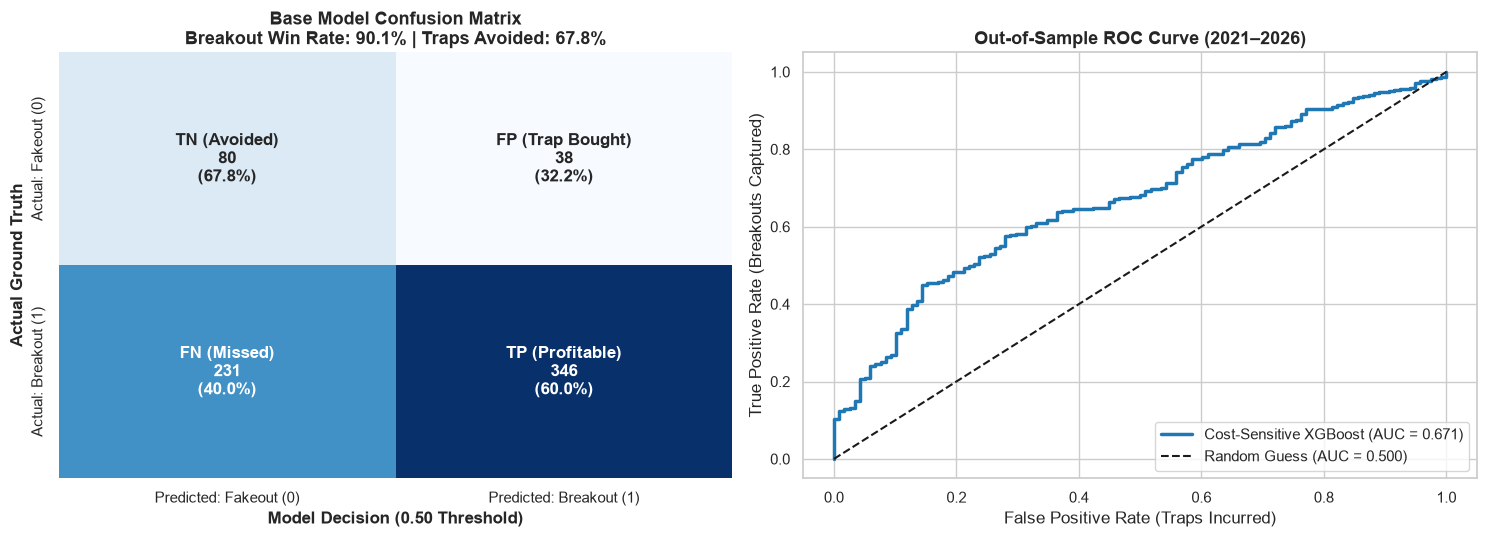

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 1. Custom Annotated Confusion Matrix
cm_labels = [
    [f"TN (Avoided)\n{tn}\n({tn/total_fakeouts*100:.1f}%)", f"FP (Trap Bought)\n{fp}\n({fp/total_fakeouts*100:.1f}%)"],
    [f"FN (Missed)\n{fn}\n({fn/total_breakouts*100:.1f}%)", f"TP (Profitable)\n{tp}\n({tp/total_breakouts*100:.1f}%)"]
]

sns.heatmap(
    cm,
    annot=cm_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
    xticklabels=["Predicted: Fakeout (0)", "Predicted: Breakout (1)"],
    yticklabels=["Actual: Fakeout (0)", "Actual: Breakout (1)"],
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)
axes[0].set_title(f"Base Model Confusion Matrix\nBreakout Win Rate: {bo_prec*100:.1f}% | Traps Avoided: {fo_rec*100:.1f}%", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Actual Ground Truth", fontweight="bold")
axes[0].set_xlabel("Model Decision (0.50 Threshold)", fontweight="bold")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"Cost-Sensitive XGBoost (AUC = {auc:.3f})", lw=2.5, color="#1f77b4")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Guess (AUC = 0.500)")
axes[1].set_title("Out-of-Sample ROC Curve (2021–2026)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("False Positive Rate (Traps Incurred)")
axes[1].set_ylabel("True Positive Rate (Breakouts Captured)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 6. Feature Importance Ranking
Identify the primary technical factors driving breakout continuation versus trap failure.


C:\Users\salah\AppData\Local\Temp\ipykernel_15356\1335640177.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi.values, y=fi.index, palette="mako")


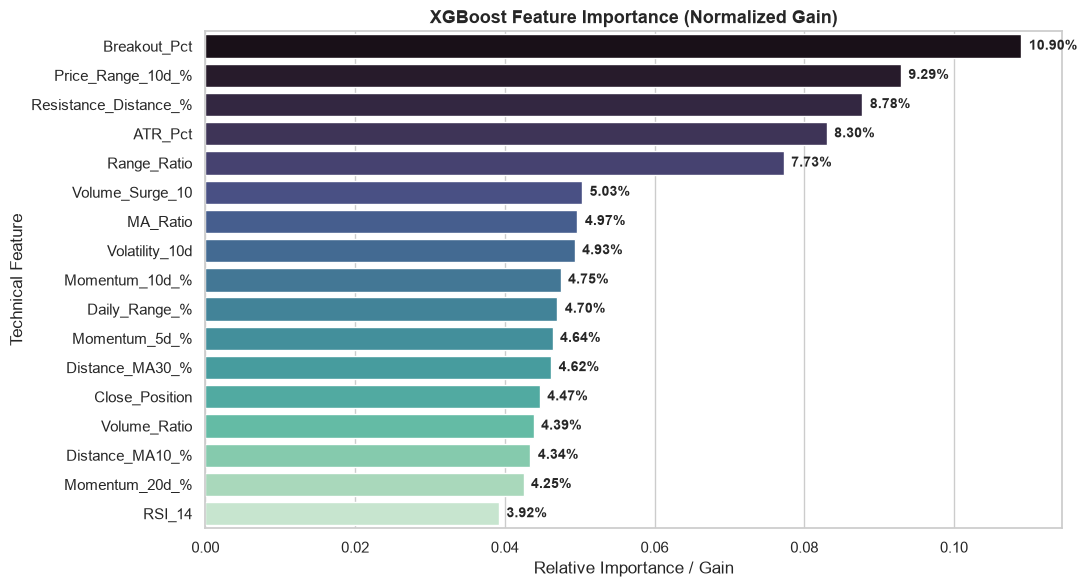

In [ ]:
fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(x=fi.values, y=fi.index, palette="mako")
plt.title("XGBoost Feature Importance (Normalized Gain)", fontsize=13, fontweight="bold")
plt.xlabel("Relative Importance / Gain")
plt.ylabel("Technical Feature")

for i, v in enumerate(fi.values):
    plt.text(v + 0.001, i, f"{v*100:.2f}%", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 7. Model Export & Production Artifacts
Save the tuned champion model and metadata schema to the `models/` directory for deployment.


In [8]:
os.makedirs("models", exist_ok=True)

model_path = "models/xgboost_breakout_champion.json"
model.save_model(model_path)

config_path = "models/model_config.json"
config = {
    "model_name": "xgboost_breakout_champion",
    "version": "2.1.0",
    "features": feature_cols,
    "target_mapping": {"fakeout": 0, "breakout": 1},
    "optimal_threshold": 0.50,
    "evaluation_metrics": {
        "breakout_precision": round(bo_prec * 100, 2),
        "fakeout_recall": round(fo_rec * 100, 2),
        "roc_auc": round(auc, 4),
        "deadly_fp_count": int(fp),
        "profitable_tp_count": int(tp)
    }
}

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"Model successfully saved to:         {model_path}")
print(f"Configuration successfully saved to: {config_path}")


Model successfully saved to:         models/xgboost_breakout_champion.json
Configuration successfully saved to: models/model_config.json
